In [1]:
from google.colab import files
uploaded = files.upload()


Saving sapphire data.csv to sapphire data.csv


In [2]:
!pip install textblob matplotlib seaborn


In [ ]:
import pandas as pd
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Load data
df = pd.read_csv('dataset.csv')

# Check the structure
print("Columns:", df.columns)
df.head()


Columns: Index(['comment'], dtype='object')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,comment
0,Ya kb launch ho rhy hn new arrivals
1,Is it available online....?
2,❤️
3,Price plz
4,Any upcoming sale?


In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

# Replace 'YourCommentColumn' with actual column name from df.columns
comment_col = df.columns[0]  # Assume first column contains comments
df["cleaned"] = df[comment_col].apply(clean_text)

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "positive"
    elif polarity < -0.1:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["cleaned"].apply(get_sentiment)
df.head()


,comment,cleaned,sentiment
0,Ya kb launch ho rhy hn new arrivals,ya kb launch ho rhy hn new arrivals,positive
1,Is it available online....?,available online,positive
2,❤️,,neutral
3,Price plz,price plz,neutral
4,Any upcoming sale?,upcoming sale,neutral


from matplotlib import pyplot as plt
import seaborn as sns
_df_5.groupby('comment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_6.groupby('cleaned').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_7.groupby('sentiment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['cleaned'].value_counts()
    for x_label, grp in _df_8.groupby('comment')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('comment')
_ = plt.ylabel('cleaned')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['sentiment'].value_counts()
    for x_label, grp in _df_9.groupby('cleaned')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('cleaned')
_ = plt.ylabel('sentiment')

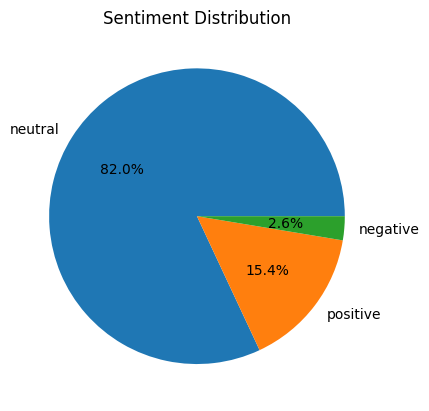

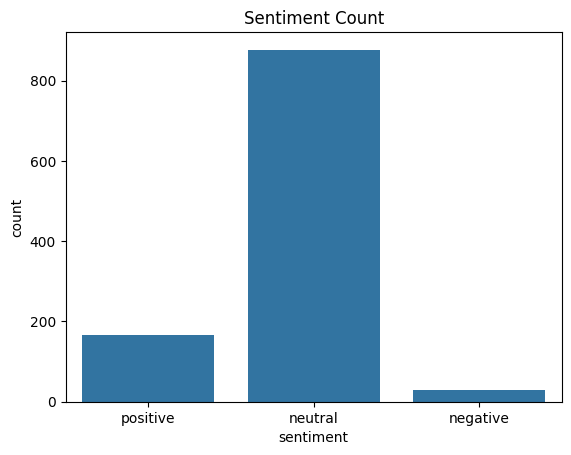

In [8]:
# Pie chart
sentiment_counts = df["sentiment"].value_counts()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

# Bar chart
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Count")
plt.show()


In [9]:
df.to_csv("sentiment_output.csv", index=False)
from google.colab import files
files.download("sentiment_output.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>